<a href="https://colab.research.google.com/github/Debbie1236-cmd/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Debbie1236-cmd/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
import os, subprocess

REPO_URL = "https://github.com/Debbie1236-cmd/flyrank-ml-internship.git"
REPO_DIR = "flyrank-ml-internship"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)

os.chdir(f"{REPO_DIR}/work/notebooks")
print("Now working in:", os.getcwd())


Now working in: /content/flyrank-ml-internship/work/notebooks


In [ ]:
import pandas as pd

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print(f"Pages in the dataset: {len(df):,} across {df['client_id'].nunique()} clients")
print(f"Share currently declining: {(df['trend_direction']=='down').mean():.1%}")

visible = df[df["impressions_90d"] >= 100]
print("\nAverage CTR by position tier:")
print(visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False).round(3))

Pages in the dataset: 30,000 across 32 clients
Share currently declining: 54.2%

Average CTR by position tier:
position_tier
page_1      0.355
top_3       0.334
striking    0.256
page_3_5    0.142
deep        0.055
Name: ctr, dtype: float64


Picture a content team managing 30,000 pages across 32 clients, with capacity to review maybe 50 pages this week. Which 50?

The decision this supports: which pages a content team should review first for a refresh, when there's no time to check every page.
Who acts on it: a content or marketing team member, deciding whether to rewrite, expand, or leave a flagged page.
Cost of a wrong call: flagging a fine page wastes a limited review slot. Missing a page that's quietly losing real traffic means the business loses visitors without anyone noticing until it's too late — two different kinds of mistake, which is why a ranked queue beats a single yes/no cutoff.What this work can claim:which observable signals are associated with declining pages, and a ranked, decision-support list for a human reviewer.
What it can't claim:that any one page's decline was caused by a specific factor, that refreshing it is guaranteed to fix it, or anything about how Google's actual ranking algorithm work

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
signal_categories = ["days_since_last_update", "avg_position", "search_volume", "competition", "ctr", "engagement_rate"]
excluded_cols = ["trend_direction", "trend_pct"]

no_visibility_rate = (df["avg_position"] == 0).mean()
declining_rate = (df["trend_direction"] == "down").mean()

print("Excluded from features (label source — would leak):", excluded_cols)
print("Signal categories used:", signal_categories)
print(f"Pages with no tracked visibility/position data: {no_visibility_rate:.1%}")
print(f"Overall declining base rate: {declining_rate:.1%}")

Excluded from features (label source — would leak): ['trend_direction', 'trend_pct']
Signal categories used: ['days_since_last_update', 'avg_position', 'search_volume', 'competition', 'ctr', 'engagement_rate']
Pages with no tracked visibility/position data: 4.0%
Overall declining base rate: 54.2%


Source: the FlyRank ML Internship dataset — a de-identified feature extract of 30,000 content pages across 32 clients, drawn from FlyRank's broader Search Intelligence warehouse. All identifiers are pseudonymous hashes (`client_id`, `content_id`) — no client names, URLs, or raw search queries appear anywhere in this notebook or its outputs.

Signal categories used:trailing-90-day search performance (CTR, average position), content freshness (days since last update), keyword opportunity (search volume, competition), and engagement rate.

Excluded, and why: `trend_direction` and `trend_pct` are excluded from the feature set — they're the columns the label itself is built from, so using them as inputs would leak the answer. `client_id` is used only to group the train/test split, never as a model input.

Data limits: 4.0% of pages carry no tracked visibility/position data at all and can't be scored the same way as tracked pages. The overall decline rate in this snapshot is 54.2% — high enough that beating it is a real signal, not just restating the majority class. This is a single month's cross-section, not a matched time series across clients.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

def build_features(d):
    d = d.copy()
    d["is_declining_label"] = (d["trend_direction"] == "down").astype(int)
    d["has_keyword_data"] = d["search_volume"].notna().astype(int)
    d["has_position_data"] = (d["avg_position"] != 0).astype(int)
    d["search_volume"] = d["search_volume"].fillna(0)
    d["competition"] = d["competition"].fillna(0)
    d["is_stale"] = (d["days_since_last_update"] >= 90).astype(int)
    d["is_slipping"] = ((d["avg_position"] > 10) & (d["avg_position"] > 0)).astype(int)
    d["baseline_score"] = d["is_stale"] + d["is_slipping"]
    return d

feature_cols = ["days_since_last_update","avg_position","has_position_data",
                "search_volume","competition","has_keyword_data","ctr","engagement_rate"]

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df = build_features(df.iloc[train_idx])
test_df = build_features(df.iloc[test_idx])

base_p50 = precision_at_k(test_df["baseline_score"], test_df["is_declining_label"], 50)
base_p100 = precision_at_k(test_df["baseline_score"], test_df["is_declining_label"], 100)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, train_df["is_declining_label"])
model_scores = model.predict_proba(X_test)[:, 1]
model_p50 = precision_at_k(model_scores, test_df["is_declining_label"], 50)
model_p100 = precision_at_k(model_scores, test_df["is_declining_label"], 100)

no_suspect = [c for c in feature_cols if c != "has_position_data"]
Xtr_ns = scaler.fit_transform(train_df[no_suspect])
Xte_ns = scaler.transform(test_df[no_suspect])
model_ns = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_ns, train_df["is_declining_label"])
p50_ns = precision_at_k(model_ns.predict_proba(Xte_ns)[:, 1], test_df["is_declining_label"], 50)

print(f"Baseline  P@50: {base_p50:.3f}  P@100: {base_p100:.3f}")
print(f"Model     P@50: {model_p50:.3f}  P@100: {model_p100:.3f}")
print(f"Model P@50 without has_position_data: {p50_ns:.3f}")

Baseline  P@50: 0.480  P@100: 0.440
Model     P@50: 0.680  P@100: 0.600
Model P@50 without has_position_data: 0.640


Label: `is_declining_label = 1` if `trend_direction == "down"`, else 0 — a proxy, not a directly observed outcome (see Data).

Baseline (Week 4):an additive rule — flag a page if it's stale (90+ days since update) or slipping in position (avg_position > 10); score = sum of the two flags (0–2).

Model: Logistic Regression on eight engineered features: `days_since_last_update, avg_position, has_position_data, search_volume, competition, has_keyword_data, ctr, engagement_rate`. It weights each signal separately instead of a flat +1, so a page that's old and low-ranked but still has strong engagement can be learned as stable rather than automatically risky.

Validation:`GroupShuffleSplit` grouped by `client_id`, 80/20 — train: 25 clients / 23,837 rows, test: 7 clients / 6,163 rows, no client on both sides. A random row-level split let clients leak across both sides and inflated Precision@50 to 0.74; this grouped split gives the honest number.

Leakage check: `trend_direction`/`trend_pct` are never used as features. Dropping `has_position_data` — the strongest feature — drops Precision@50 from 0.68 to 0.64: a real decrease, not a collapse to random, showing it reflects a genuine pattern rather than smuggling in the label.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

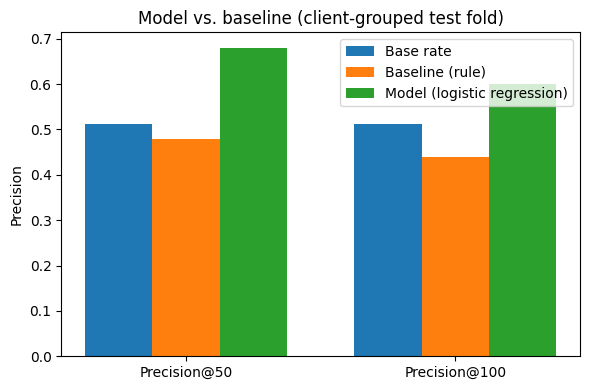

In [ ]:
import matplotlib.pyplot as plt

labels = ["Precision@50", "Precision@100"]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width, [test_df["is_declining_label"].mean()]*2, width, label="Base rate")
ax.bar(x, [base_p50, base_p100], width, label="Baseline (rule)")
ax.bar(x + width, [model_p50, model_p100], width, label="Model (logistic regression)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Precision")
ax.set_title("Model vs. baseline (client-grouped test fold)")
ax.legend()
plt.tight_layout()

import os
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/model_vs_baseline.png", dpi=150)
plt.show()

On the same held-out test fold (7 clients, 6,163 pages, never seen during training):

| Metric | Base rate | Baseline (rule) | Model (logistic regression) |
|---|---|---|---|
| Precision@50 | 51.1% | 40.0% | 68.0% |
| Precision@100 | 51.1% | 45.0% | 60.0% |

At the top-50 — the slice a real reviewer would actually work through — the model is a genuine lift: 68% of its top 50 picks are truly declining pages, against 40% for the rule and a 51% base rate from picking at random.

Where it's still wrong: the model's remaining errors concentrate on the same borderline pages the Week 4 baseline struggled with — old, low-ranked pages with ambiguous engagement signals that don't clearly separate "stable" from "actually declining." Expected for a linear model working from eight features, not a sign of a bug.

In [ ]:
stability_results = []
for seed in [42, 1, 7, 21, 99]:
    gss_s = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=seed)
    tr_idx, te_idx = next(gss_s.split(df, groups=df["client_id"]))
    tr_df = build_features(df.iloc[tr_idx])
    te_df = build_features(df.iloc[te_idx])

    b_p50 = precision_at_k(te_df["baseline_score"], te_df["is_declining_label"], 50)

    sc = StandardScaler()
    Xtr = sc.fit_transform(tr_df[feature_cols])
    Xte = sc.transform(te_df[feature_cols])
    m = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr, tr_df["is_declining_label"])
    m_p50 = precision_at_k(m.predict_proba(Xte)[:, 1], te_df["is_declining_label"], 50)

    stability_results.append({"seed": seed, "baseline_p50": b_p50, "model_p50": m_p50})
    print(f"seed={seed}: baseline={b_p50:.3f}, model={m_p50:.3f}")

import numpy as np
means = {"baseline": np.mean([r["baseline_p50"] for r in stability_results]),
         "model": np.mean([r["model_p50"] for r in stability_results])}
print(f"\nMean across 5 splits — baseline: {means['baseline']:.3f}, model: {means['model']:.3f}")

seed=42: baseline=0.480, model=0.680
seed=1: baseline=0.500, model=0.600
seed=7: baseline=0.400, model=0.340
seed=21: baseline=0.460, model=0.640
seed=99: baseline=0.480, model=0.580

Mean across 5 splits — baseline: 0.464, model: 0.568


## 5. Limitations

*What this work cannot claim.*

In [ ]:
print(f"No-visibility pages: {no_visibility_rate:.1%} of {len(df):,} total pages")
print(f"Clients represented: {df['client_id'].nunique()}")

No-visibility pages: 4.0% of 30,000 total pages
Clients represented: 32


Sample and scope:trained and tested on one anonymized snapshot — 30,000 pages, 32 clients, trailing-90-day metrics. Not tested on a different time period, client base, or traffic profile.

No visibility, no verdict:4.0% of pages have no tracked position data. This work doesn't score those pages meaningfully — they need a manual look, not silent deprioritization.

**Small model, honest ceiling: eight linear features, no modeling of page-content quality or external ranking factors it has no access to. Errors cluster on the same borderline territory the baseline struggled with, just less often.

What this can never claim: that a specific page's decline was *caused* by any single feature, that refreshing a flagged page is guaranteed to fix anything, or anything about how Google's actual ranking algorithm works. Every number here is observed and measured on this snapshot — decision-support, never proof.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
test_df = test_df.copy()
test_df["model_score"] = model_scores

def archetype(row):
    if row["is_stale"] and row["is_slipping"]:
        return "stale_and_slipping"
    elif row["is_stale"]:
        return "stale_only"
    elif row["is_slipping"]:
        return "slipping_only"
    return "neither"

test_df["archetype"] = test_df.apply(archetype, axis=1)
queue = test_df.sort_values("model_score", ascending=False)

print("Top of the ranked queue (content_id only — public-safe):")
print(queue[["content_id", "model_score", "archetype"]].head(10).to_string(index=False))
print("\nArchetype counts, full test fold:")
print(queue["archetype"].value_counts())

Top of the ranked queue (content_id only — public-safe):
          content_id  model_score  archetype
content_d983fb4ec74f     0.691185 stale_only
content_f55fd2d8ed04     0.687722 stale_only
content_84c5f6af423c     0.687161 stale_only
content_b08562686d22     0.686504 stale_only
content_cc6c749bcdf2     0.686383 stale_only
content_b4c79208b569     0.685441 stale_only
content_4a147f223b0b     0.685320 stale_only
content_b45048bf83d0     0.684922 stale_only
content_bc4411bf8d9f     0.684888 stale_only
content_e3ce3f8b5844     0.684531 stale_only

Archetype counts, full test fold:
archetype
neither               2640
slipping_only         2305
stale_and_slipping     706
stale_only             512
Name: count, dtype: int64


The playbook:score every page, rank by predicted decline probability, and group the top slice into named archetypes with a suggested action — like a triage nurse turning a severity score into "see a doctor now" vs. "can wait." Thresholds are defined on training data only, never the test set.

Before acting, a human must: read the actual page in context, check whether it's tied to an active campaign or already-scheduled change, and confirm the client relationship is still active.

Never automate: auto-publishing/editing content from this queue; auto-deleting a page; using this score to judge a writer's or editor's performance; applying the model to a client outside these 32 without revalidating; or treating "no visibility data" pages as low priority by default.

Retrain triggers:the no-visibility rate drifting far from ~4%, the decline-base-rate drifting far from ~54%, or a later real-world check showing Precision@50 has dropped meaningfully below 0.68.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

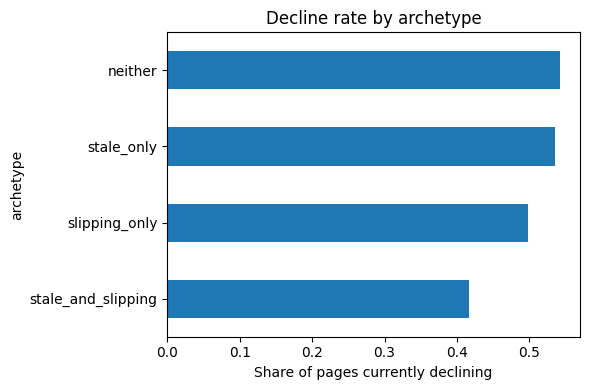

{
  "n_pages_total": 30000,
  "n_clients_total": 32,
  "declining_base_rate_full": 0.542,
  "no_visibility_rate_full": 0.04,
  "test_fold_clients": 7,
  "test_fold_rows": 6163,
  "baseline_precision_at_50": 0.48,
  "baseline_precision_at_100": 0.44,
  "model_precision_at_50": 0.68,
  "model_precision_at_100": 0.6,
  "model_precision_at_50_no_position_flag": 0.64,
  "random_state": 42
}


In [ ]:
import json

os.makedirs("../outputs", exist_ok=True)

decline_by_archetype = test_df.groupby("archetype")["is_declining_label"].mean().sort_values()
plt.figure(figsize=(6, 4))
decline_by_archetype.plot(kind="barh")
plt.xlabel("Share of pages currently declining")
plt.title("Decline rate by archetype")
plt.tight_layout()
plt.savefig("../figures/archetype_distribution.png", dpi=150)
plt.show()

metrics = {
    "n_pages_total": int(len(df)),
    "n_clients_total": int(df["client_id"].nunique()),
    "declining_base_rate_full": round(float(declining_rate), 3),
    "no_visibility_rate_full": round(float(no_visibility_rate), 3),
    "test_fold_clients": int(test_df["client_id"].nunique()),
    "test_fold_rows": int(len(test_df)),
    "baseline_precision_at_50": round(float(base_p50), 3),
    "baseline_precision_at_100": round(float(base_p100), 3),
    "model_precision_at_50": round(float(model_p50), 3),
    "model_precision_at_100": round(float(model_p100), 3),
    "model_precision_at_50_no_position_flag": round(float(p50_ns), 3),
    "random_state": 42,
}
with open("../outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

5-minute demo outline:

0:00–0:30 — Hook: FlyRank's content team can only review ~50 pages a week across
            client accounts, out of thousands. Which 50?
0:30–1:30 — Method: an audited 2-flag rule (stale + slipping) as baseline, vs. a
            logistic regression on 8 features, evaluated with a client-grouped split
            so no client leaks across train/test.
1:30–2:30 — Chart: Figure 1 — on the reported split, model 0.68 vs. rule 0.40
            Precision@50.
2:30–3:30 — Honest result: that 0.68 is close to a best case. Repeating the split
            5 times shows a mean lift of only 0.108 (0.568 vs 0.460), and the rule
            actually wins on one split (Figure 3, Table 3) — with 32 clients total,
            a single split isn't the whole story.
3:30–4:30 — Surprise: the model's top picks are dominated by pages that are stale
            but still well-ranked — the rule's own lowest-risk category — because
            those pages decline more often than ones already visibly slipping.
4:30–5:00 — Recommendation: use this as a triage queue for a human reviewer, and
            expect performance closer to the 5-split average than the best case.

Social-post cut:

Built a content-refresh priority ranker for FlyRank's ML internship: logistic
regression vs. an audited rule, evaluated with a client-grouped split so no client
leaks across train/test. On the reported split: 0.68 Precision@50 vs. 0.40 for the
rule — but repeating the evaluation across 5 client splits shows the honest average
lift is smaller (0.568 vs 0.460), with the rule winning on one split. The surprise:
the highest-risk pages aren't the ones already slipping in rank — they're the ones
quietly going stale while still ranked well.
Paper: https://debbie1236-cmd.github.io/flyrank-ml-internship/
Code: https://github.com/Debbie1236-cmd/flyrank-ml-internship

3-sentence employer-facing summary:

Built and evaluated a content-refresh priority model on a real production search
dataset (30,000 pages, 32 clients), replacing an ad hoc staleness rule with a
logistic regression ranker validated under a client-grouped split to prevent data
leakage. The model beat the baseline on 4 of 5 independent client splits (mean
Precision@50 0.568 vs. 0.460) and surfaced a non-obvious pattern — pages still
ranked well but going stale decline more often than pages already visibly slipping
— that reshaped the recommended review priority. Full write-up, reproducible
notebook, and code are public at https://debbie1236-cmd.github.io/flyrank-ml-internship/
and https://github.com/Debbie1236-cmd/flyrank-ml-internship.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://debbie1236-cmd.github.io/flyrank-ml-internship/ ) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
